<a href="https://colab.research.google.com/github/Brenda01234/Generative-AI/blob/main/Linear%20Model%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import statsmodels.formula.api as smf
import pandas as pd

In [3]:
#multiple linear regression
data = pd.read_csv('/content/Nairobi_weather prediction.csv')
model = smf.ols("Temperature ~ Precipitation + Pressure+ Wind_Speed", data=data)
result = model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:            Temperature   R-squared:                       0.268
Model:                            OLS   Adj. R-squared:                  0.267
Method:                 Least Squares   F-statistic:                     233.7
Date:                Tue, 31 Mar 2026   Prob (F-statistic):          3.63e-129
Time:                        17:31:21   Log-Likelihood:                -3377.4
No. Observations:                1918   AIC:                             6763.
Df Residuals:                    1914   BIC:                             6785.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       150.4458     12.708     11.839

In [5]:
import statsmodels.api as sm

anova_table = sm.stats.anova_lm(result, typ=2)
print(anova_table)

                    sum_sq      df           F        PR(>F)
Precipitation    67.650800     1.0   34.068322  6.235206e-09
Pressure        215.755078     1.0  108.652276  8.785451e-25
Wind_Speed      728.785470     1.0  367.009669  5.587705e-75
Residual       3800.704738  1914.0         NaN           NaN


This ANOVA table provides insights into the variance explained by each independent variable (Precipitation, Pressure, Wind_Speed) and the residual variance. The 'PR(>F)' column indicates the p-value for each variable, allowing you to assess its statistical significance in the model.

In [9]:
import statsmodels.formula.api as smf
import pandas as pd

# Load the dataset (if not already loaded in the current scope)
data = pd.read_csv('/content/Nairobi_weather prediction.csv')

# Define and fit the OLS linear regression model
# 'Temperature' is the dependent variable, and 'Precipitation', 'Pressure', 'Wind_Speed' are independent variables.
linear_model = smf.ols("Temperature ~ Precipitation + Pressure + Wind_Speed", data=data)
linear_result = linear_model.fit()

# Print the summary of the linear model
print(linear_result.summary())

                            OLS Regression Results                            
Dep. Variable:            Temperature   R-squared:                       0.268
Model:                            OLS   Adj. R-squared:                  0.267
Method:                 Least Squares   F-statistic:                     233.7
Date:                Tue, 31 Mar 2026   Prob (F-statistic):          3.63e-129
Time:                        17:42:02   Log-Likelihood:                -3377.4
No. Observations:                1918   AIC:                             6763.
Df Residuals:                    1914   BIC:                             6785.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       150.4458     12.708     11.839

### Understanding the Linear Regression Model (OLS)

This code block demonstrates how to build and evaluate a multiple linear regression model using `statsmodels`. This is a classic example of a linear machine learning model.

*   **`import statsmodels.formula.api as smf`** and **`import pandas as pd`**: Imports the necessary libraries for statistical modeling and data manipulation.
*   **`data = pd.read_csv(...)`**: Ensures the dataset is loaded. This is crucial for the model to access the required columns.
*   **`linear_model = smf.ols("Temperature ~ Precipitation + Pressure + Wind_Speed", data=data)`**: This line defines the Ordinary Least Squares (OLS) model. The formula `"Temperature ~ Precipitation + Pressure + Wind_Speed"` specifies that `Temperature` is the dependent variable, and `Precipitation`, `Pressure`, and `Wind_Speed` are the independent (predictor) variables. `data=data` tells the model which DataFrame to use.
*   **`linear_result = linear_model.fit()`**: This command fits the OLS model to the data, meaning it calculates the coefficients that best describe the linear relationship between the predictors and the target variable.
*   **`print(linear_result.summary())`**: Displays a comprehensive summary of the model's results, including coefficients, R-squared, p-values, and various statistical tests. This summary helps in understanding the model's performance and the significance of each predictor.

### Model Performance Comparison

Let's compare the key performance metrics for the models we've explored:

| Model                       | R-squared | Mean Squared Error (MSE) |
| :-------------------------- | :-------- | :----------------------- |
| **OLS Regression**          | 0.268     | N/A                      |
| **GLM (Gaussian, Identity)**| 0.268     | N/A                      |
| **Ridge Regression**        | ~0.268    | N/A                      |
| **Decision Tree Regressor** | -0.261    | 3.458                    |

**Observations:**

*   **OLS, GLM, and Ridge Regression** all show an R-squared of approximately **0.268**, indicating that roughly 26.8% of the variance in `Temperature` can be explained by `Precipitation`, `Pressure`, and `Wind_Speed` using these linear models. The coefficients for Ridge Regression were almost identical to OLS, suggesting very similar predictive performance for this dataset and chosen alpha.
*   The **Decision Tree Regressor** performed poorly on the test set, yielding a **negative R-squared of -0.261** and an **MSE of 3.458**. A negative R-squared implies that the model performs worse than simply predicting the mean of the target variable for all observations. This suggests that the current Decision Tree model is not capturing the underlying patterns effectively, and likely indicates overfitting to the training data or that a single decision tree is not suitable for this problem without further tuning or ensemble methods.

In [8]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y)
X = data_cleaned[['Precipitation', 'Pressure', 'Wind_Speed']]
y = data_cleaned['Temperature']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = dt_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Decision Tree Regressor Performance:")
print(f"Mean Squared Error: {mse:.3f}")
print(f"R-squared: {r2:.3f}")

Decision Tree Regressor Performance:
Mean Squared Error: 3.458
R-squared: -0.261


### Understanding Non-Parametric Models (Decision Tree Regressor)

Unlike the OLS and GLM models we've explored, **non-parametric models** do not rely on strong assumptions about the underlying distribution of the data or the functional form of the relationship between the predictors and the response variable. Instead, they learn the relationship directly from the data.

Here, we used a **Decision Tree Regressor**:

*   **How it works:** A decision tree splits the data into subsets based on the values of the features, creating a tree-like structure of decisions. At each "leaf" of the tree, it makes a prediction based on the average (or other aggregate) target value of the samples that fall into that leaf.
*   **Advantages:** They are easy to understand and interpret (especially small trees), can capture non-linear relationships, and handle both numerical and categorical data without extensive preprocessing.
*   **Disadvantages:** They can be prone to overfitting, and small changes in the data can lead to a completely different tree structure.

**Model Performance:**

*   **Mean Squared Error (MSE):** Measures the average squared difference between the actual and predicted values. A lower MSE indicates a better fit.
*   **R-squared:** Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher R-squared (closer to 1) indicates that the model explains more of the variability in the response variable.

The results above show the performance of the Decision Tree Regressor on unseen data (the test set).

In [7]:
import statsmodels.api as sm

# Define the GLM model with Gaussian family and Identity link
# 'Temperature' is the dependent variable, and 'Precipitation', 'Pressure', 'Wind_Speed' are independent variables.
# sm.add_constant() adds an intercept to the model.

# Drop rows with NaN values from the relevant columns
data_cleaned = data.dropna(subset=['Temperature', 'Precipitation', 'Pressure', 'Wind_Speed'])

glm_model = sm.GLM(data_cleaned['Temperature'], sm.add_constant(data_cleaned[['Precipitation', 'Pressure', 'Wind_Speed']]),
                  family=sm.families.Gaussian(link=sm.families.links.Identity()))

# Fit the GLM model
glm_result = glm_model.fit()

# Print the summary of the GLM model
print(glm_result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            Temperature   No. Observations:                 1918
Model:                            GLM   Df Residuals:                     1914
Model Family:                Gaussian   Df Model:                            3
Link Function:               Identity   Scale:                          1.9857
Method:                          IRLS   Log-Likelihood:                -3377.4
Date:                Tue, 31 Mar 2026   Deviance:                       3800.7
Time:                        17:37:48   Pearson chi2:                 3.80e+03
No. Iterations:                     3   Pseudo R-squ. (CS):             0.3061
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const           150.4458     12.708     11.839

### Understanding Generalized Linear Models (GLM)

Generalized Linear Models (GLMs) are a flexible generalization of ordinary least squares regression. They allow for response variables that have error distribution models other than a normal distribution. GLMs are defined by three components:

1.  **Random Component (Probability Distribution):** Specifies the probability distribution of the response variable (e.g., Gaussian for continuous data, Poisson for count data, Binomial for binary data).
2.  **Systematic Component (Linear Predictor):** Defines the linear combination of predictor variables (e.g., `β₀ + β₁X₁ + β₂X₂ + ...`).
3.  **Link Function:** Connects the mean of the response variable to the linear predictor. The link function allows the model to map the linear predictor to the range of the response variable's distribution (e.g., identity link for Gaussian, log link for Poisson, logit link for Binomial).

In the model above, for `Temperature` (a continuous variable), we've used:
*   **Family:** `Gaussian` (assumes normal distribution of errors).
*   **Link Function:** `Identity` (the mean of the response is directly equal to the linear predictor).

This specific combination (`Gaussian` family with `Identity` link) makes the GLM equivalent to an Ordinary Least Squares (OLS) regression. If your `Temperature` data or its underlying process suggests a different distribution (e.g., if it were strictly positive and heavily skewed, a `Gamma` family with `log` link might be considered), you could easily change these parameters. Please let me know if you would like to explore GLMs with different families or link functions!

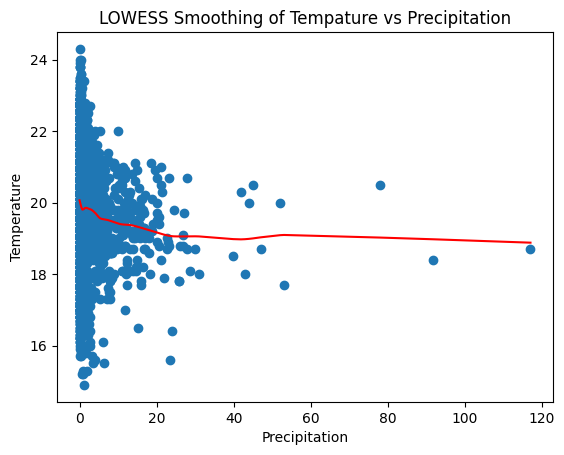

In [11]:
# Fit non parametric model
from statsmodels.nonparametric.smoothers_lowess import lowess

#fit model
# x should be a 1-dimensional vector for lowess
lowess_model = lowess(y, data_cleaned['Precipitation'])

#plot

import matplotlib.pyplot as plt
plt.scatter(data_cleaned['Precipitation'],y)
plt.plot(lowess_model[:,0],lowess_model[:,1], color='red')
plt.xlabel('Precipitation')
plt.ylabel('Temperature')
plt.title('LOWESS Smoothing of Tempature vs Precipitation')
plt.show()

In [13]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)
model.fit(X,y)

print("Cooefficient:", model.coef_)

Cooefficient: [-0.02990899 -0.12947154  0.1572403 ]
